# Dataset Comparison: CimaIO vs Seckin

This notebook compares aggregated statistics from CimaIO datasets vs Seckin datasets.

**Comparison approach:**
- Aggregate all users from all CimaIO datasets → compute mean ± std for IO vs control
- Aggregate all users from all Seckin datasets → compute mean ± std for IO vs control

**Metrics:**
1. Number of posts per user (IO vs control)
2. Number of active days per user (IO vs control)

In [1]:
# Imports and repo setup
from pathlib import Path
import sys
from collections import Counter, defaultdict
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Locate repository root (contains src/)
repo_root = Path.cwd()
for _ in range(3):
    if (repo_root / "src").exists():
        break
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_loader import import_data

In [2]:
def load_dataset(path):
    """Load dataset from cache file or using import_data."""
    cache_path = Path(path) / "data_cache.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            data = pickle.load(f)
            if isinstance(data, dict):
                RTs = data.get("RTs", [])
                io_users = data.get("io_users", [])
            else:
                RTs, io_users = data
    else:
        RTs, io_users = import_data(str(path), use_cache=True)
    return RTs, set(io_users)

In [3]:
def analyze_dataset(RTs, io_set):
    """Analyze posts per user and active days for IO and control users."""
    io_posts = Counter()
    control_posts = Counter()
    io_days = defaultdict(set)
    control_days = defaultdict(set)
    
    for user_id, tweet_id, ts in RTs:
        date = ts.date()
        if user_id in io_set:
            io_posts[user_id] += 1
            io_days[user_id].add(date)
        else:
            control_posts[user_id] += 1
            control_days[user_id].add(date)
    
    # Convert days sets to counts
    io_days_count = {user: len(days) for user, days in io_days.items()}
    control_days_count = {user: len(days) for user, days in control_days.items()}
    
    return {
        'io_posts': dict(io_posts),
        'control_posts': dict(control_posts),
        'io_days': io_days_count,
        'control_days': control_days_count
    }

In [4]:
def compute_statistics(data_dict):
    """Compute mean and median statistics."""
    values = list(data_dict.values())
    if not values:
        return {"count": 0, "mean": 0, "median": 0, "std": 0, "total": 0}
    return {
        "count": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "std": np.std(values),
        "total": sum(values),
    }


def build_metric_table(results, collection_key, metric_key):
    """
    Build a per-dataset table for a given metric.

    metric_key: 'posts' or 'days'
    collection_key: 'cima' or 'seckin'
    """
    rows = []
    for name, result in results.items():
        data = result.get(collection_key)
        if not data:
            continue
        io_stats = compute_statistics(data[f"io_{metric_key}"])
        control_stats = compute_statistics(data[f"control_{metric_key}"])
        rows.append(
            {
                "Dataset": name,
                "IO Mean": io_stats["mean"],
                "IO Std": io_stats["std"],
                "Control Mean": control_stats["mean"],
                "Control Std": control_stats["std"],
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df = df.sort_values("Dataset").reset_index(drop=True)

    # Mean across datasets with final deviation (std across dataset means)
    io_mean = df["IO Mean"].mean()
    io_std = df["IO Mean"].std(ddof=0)
    control_mean = df["Control Mean"].mean()
    control_std = df["Control Mean"].std(ddof=0)

    summary = pd.DataFrame(
        [
            {
                "Dataset": "Across datasets",
                "IO Mean": io_mean,
                "IO Std": io_std,
                "Control Mean": control_mean,
                "Control Std": control_std,
            }
        ]
    )

    return pd.concat([df, summary], ignore_index=True)

## Load Datasets

In [5]:
# Define dataset pairs to compare
# CimaIO datasets available
cima_datasets = ['Honduras', 'UAE']

# All Seckin datasets in data/
seckin_datasets = [
    'Armenia', 'Bangladesh', 'Catalonia', 'China_1', 'China_2', 'Cuba', 
    'Ecuador', 'Egypt_UAE', 'Ghana_Nigeria', 'Iran_1', 'Iran_2', 'Iran_3', 
    'Iran_4', 'Iran_5', 'Iran_6', 'Qatar', 'Russia_1', 'Russia_2', 'Russia_3', 
    'Russia_4', 'Russia_5', 'Spain', 'Thailand', 'UAE', 'Venezuela_1', 'Venezuela_2'
]

# Build dataset pairs for CimaIO vs Seckin comparison
dataset_pairs = []

# Add CimaIO datasets (comparing with themselves in Seckin)
for name in cima_datasets:
    cima_path = f'../datasets/CimaIO/{name}/Processed'
    dataset_pairs.append(('CimaIO', name, cima_path, None))

# Add all Seckin-only datasets (no CimaIO equivalent, will load only Seckin)
for name in seckin_datasets:
    if name not in cima_datasets:
        seckin_path = f'../data/{name}/Processed'
        dataset_pairs.append(('Seckin', name, None, seckin_path))

results = {}
print(f"Total dataset pairs to analyze: {len(dataset_pairs)}")

Total dataset pairs to analyze: 27


In [6]:
# Load and analyze all datasets
for dataset_type, name, cima_path, seckin_path in dataset_pairs:
    print(f"\n{'='*60}")
    print(f"Processing: {name} ({dataset_type})")
    print(f"{'='*60}")
    
    result_entry = {'type': dataset_type}
    
    # Load CimaIO dataset if available
    if cima_path:
        print(f"\nLoading CimaIO dataset from {cima_path}...")
        try:
            cima_RTs, cima_io_set = load_dataset(cima_path)
            print(f"  Total retweets: {len(cima_RTs):,}")
            print(f"  IO users: {len(cima_io_set):,}")
            
            print(f"  Analyzing CimaIO dataset...")
            cima_analysis = analyze_dataset(cima_RTs, cima_io_set)
            result_entry['cima'] = cima_analysis
            result_entry['cima_io_count'] = len(cima_io_set)
        except Exception as e:
            print(f"  Error loading CimaIO dataset: {e}")
            result_entry['cima'] = None
    
    # Load Seckin dataset
    if seckin_path:
        print(f"\nLoading Seckin dataset from {seckin_path}...")
        try:
            seckin_RTs, seckin_io_set = load_dataset(seckin_path)
            print(f"  Total retweets: {len(seckin_RTs):,}")
            print(f"  IO users: {len(seckin_io_set):,}")
            
            print(f"  Analyzing Seckin dataset...")
            seckin_analysis = analyze_dataset(seckin_RTs, seckin_io_set)
            result_entry['seckin'] = seckin_analysis
            result_entry['seckin_io_count'] = len(seckin_io_set)
        except Exception as e:
            print(f"  Error loading Seckin dataset: {e}")
            result_entry['seckin'] = None
    
    results[name] = result_entry
    print("  Done!")

print(f"\n{'='*60}")
print(f"Successfully loaded {len(results)} datasets")
print(f"{'='*60}")


Processing: Honduras (CimaIO)

Loading CimaIO dataset from ../datasets/CimaIO/Honduras/Processed...
  Total retweets: 1,028,441
  IO users: 1,643
  Analyzing CimaIO dataset...
  Done!

Processing: UAE (CimaIO)

Loading CimaIO dataset from ../datasets/CimaIO/UAE/Processed...
  Total retweets: 2,183,766
  IO users: 1,829
  Analyzing CimaIO dataset...
  Done!

Processing: Armenia (Seckin)

Loading Seckin dataset from ../data/Armenia/Processed...
  Total retweets: 35,689
  IO users: 26
  Analyzing Seckin dataset...
  Done!

Processing: Bangladesh (Seckin)

Loading Seckin dataset from ../data/Bangladesh/Processed...
  Total retweets: 17,660
  IO users: 4
  Analyzing Seckin dataset...
  Done!

Processing: Catalonia (Seckin)

Loading Seckin dataset from ../data/Catalonia/Processed...
  Total retweets: 101,532
  IO users: 74
  Analyzing Seckin dataset...
  Done!

Processing: China_1 (Seckin)

Loading Seckin dataset from ../data/China_1/Processed...
  Total retweets: 1,382,458
  IO users: 460


## Aggregated Comparison: CimaIO vs Seckin

Each table lists per-dataset mean and deviation for IO vs control. The final row ("Across datasets") reports the mean across dataset means, with the final deviation as the std across dataset means for each scenario.

In [7]:
# Build tables for each collection and metric
cima_posts_table = build_metric_table(results, "cima", "posts")
seckin_posts_table = build_metric_table(results, "seckin", "posts")

cima_days_table = build_metric_table(results, "cima", "days")
seckin_days_table = build_metric_table(results, "seckin", "days")

print("CimaIO - Retweets per user (IO vs Control)")
display(cima_posts_table.style.format("{:.2f}", subset=["IO Mean", "IO Std", "Control Mean", "Control Std"]))

print("Seckin - Retweets per user (IO vs Control)")
display(seckin_posts_table.style.format("{:.2f}", subset=["IO Mean", "IO Std", "Control Mean", "Control Std"]))

print("CimaIO - Active days per user (IO vs Control)")
display(cima_days_table.style.format("{:.2f}", subset=["IO Mean", "IO Std", "Control Mean", "Control Std"]))

print("Seckin - Active days per user (IO vs Control)")
display(seckin_days_table.style.format("{:.2f}", subset=["IO Mean", "IO Std", "Control Mean", "Control Std"]))

CimaIO - Retweets per user (IO vs Control)


,Dataset,IO Mean,IO Std,Control Mean,Control Std
0,Honduras,5.40,23.13,4.92,20.32
1,UAE,85.02,152.61,5.45,35.23
2,Across datasets,45.21,39.81,5.19,0.27


Seckin - Retweets per user (IO vs Control)


,Dataset,IO Mean,IO Std,Control Mean,Control Std
0,Armenia,20.08,13.14,26.46,43.36
1,Bangladesh,255.00,329.93,26.20,50.12
2,Catalonia,82.38,232.34,38.78,52.09
3,China_1,774.03,9389.49,30.72,39.93
4,China_2,4042.59,42443.48,16.80,25.73
5,Cuba,6804.81,15842.61,27.19,40.93
6,Ecuador,1278.21,2320.03,26.22,46.54
7,Egypt_UAE,342.30,1565.81,29.80,32.20
8,Ghana_Nigeria,281.21,836.99,30.64,32.29
9,Iran_1,397.84,933.06,23.86,30.15


CimaIO - Active days per user (IO vs Control)


,Dataset,IO Mean,IO Std,Control Mean,Control Std
0,Honduras,3.17,6.99,3.28,6.50
1,UAE,18.57,16.29,3.49,7.62
2,Across datasets,10.87,7.70,3.38,0.11


Seckin - Active days per user (IO vs Control)


,Dataset,IO Mean,IO Std,Control Mean,Control Std
0,Armenia,3.12,2.24,1.06,0.51
1,Bangladesh,71.50,73.70,1.03,0.39
2,Catalonia,39.00,76.57,1.11,0.48
3,China_1,35.45,111.30,1.04,0.27
4,China_2,102.16,263.84,1.02,0.17
5,Cuba,142.43,189.76,1.10,0.81
6,Ecuador,77.11,179.26,1.06,0.51
7,Egypt_UAE,33.86,80.72,1.00,0.06
8,Ghana_Nigeria,40.26,63.80,1.01,0.11
9,Iran_1,75.40,106.49,1.01,0.13


## Visualizations

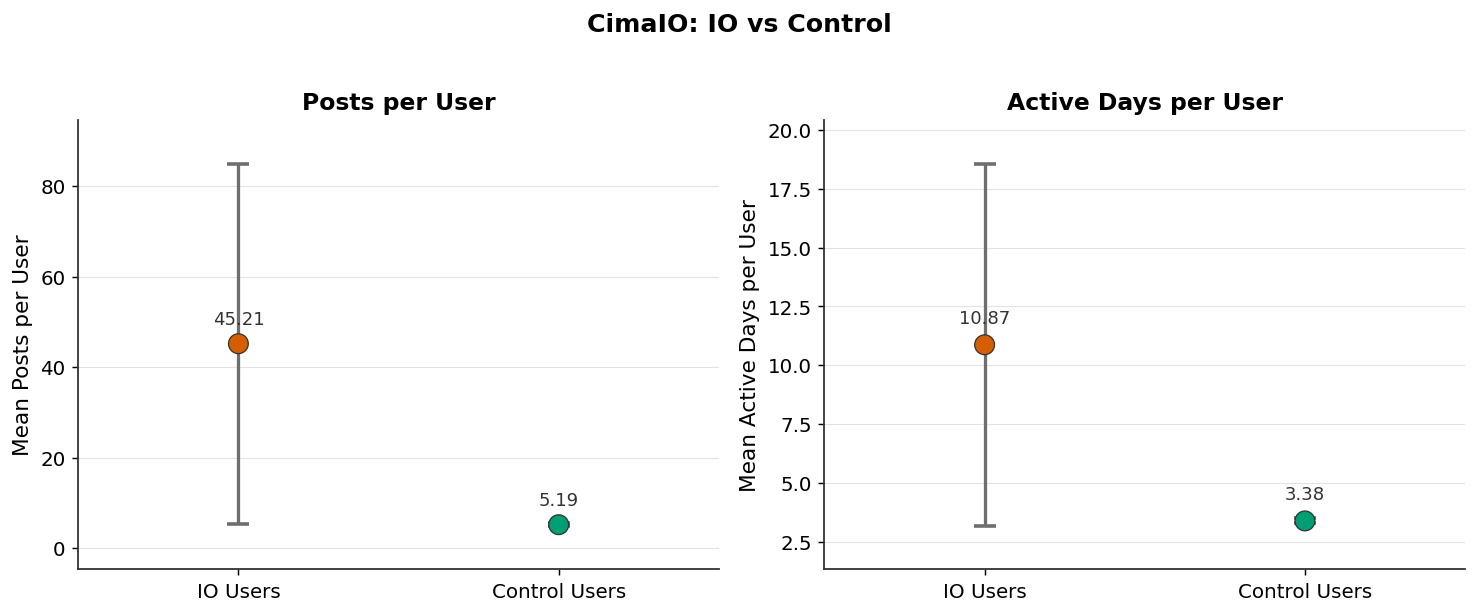

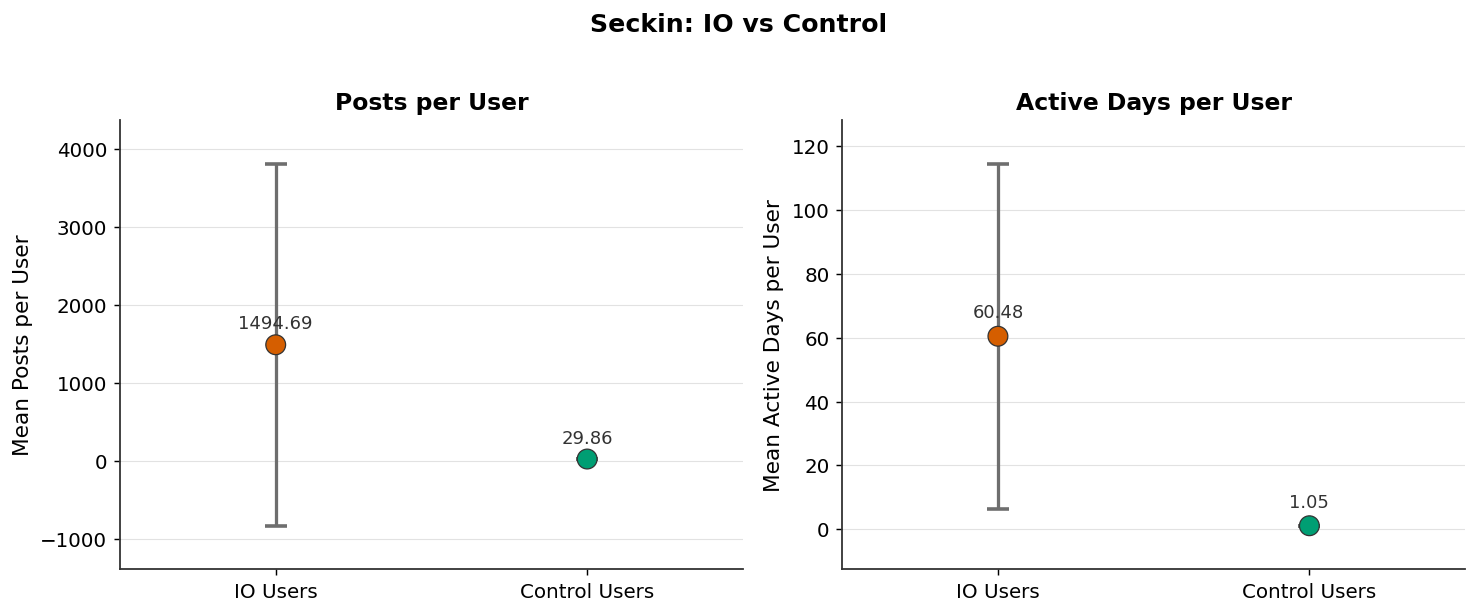

In [30]:
# Publication-style comparison figure: two panels per dataset (Posts + Active Days)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.0,
    "grid.color": "#d0d0d0",
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
})


def _summary_from_table(table):
    if table is None or table.empty:
        return 0.0, 0.0, 0.0, 0.0
    summary = table[table["Dataset"] == "Across datasets"].iloc[0]
    return (
        float(summary["IO Mean"]),
        float(summary["IO Std"]),
        float(summary["Control Mean"]),
        float(summary["Control Std"]),
    )


def _plot_panel(ax, metric_title, io_mean, io_std, control_mean, control_std, ylabel):
    x = np.array([0, 1])
    means = np.array([io_mean, control_mean])
    stds = np.array([io_std, control_std])
    labels = ["IO Users", "Control Users"]
    colors = ["#d55e00", "#009e73"]  # colorblind-friendly palette

    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="+",
        markersize=10,
        markeredgewidth=2.0,
        capsize=6,
        elinewidth=1.8,
        color="#333333",
        ecolor="#6e6e6e",
        zorder=2,
    )
    ax.scatter(x, means, s=120, c=colors, edgecolor="#333333", linewidth=0.7, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(metric_title, fontweight="semibold")
    ax.grid(axis="y", alpha=0.6, zorder=0)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    y_max = (means + stds).max() if len(means) else 0
    y_offset = 0.04 * y_max if y_max else 0.1
    for xi, mean_val in zip(x, means):
        ax.text(
            xi,
            mean_val + y_offset,
            f"{mean_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="#333333",
        )

    ax.set_xlim(-0.5, 1.5)
    ax.margins(y=0.12)


def _plot_dataset_figure(dataset_label, posts_stats, days_stats):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=False)
    fig.suptitle(f"{dataset_label}: IO vs Control", fontsize=14, fontweight="semibold", y=1.02)

    _plot_panel(
        axes[0],
        "Posts per User",
        posts_stats[0],
        posts_stats[1],
        posts_stats[2],
        posts_stats[3],
        "Mean Posts per User",
    )
    _plot_panel(
        axes[1],
        "Active Days per User",
        days_stats[0],
        days_stats[1],
        days_stats[2],
        days_stats[3],
        "Mean Active Days per User",
    )

    plt.tight_layout()
    plt.show()


cima_posts_stats = _summary_from_table(cima_posts_table)
seckin_posts_stats = _summary_from_table(seckin_posts_table)
cima_days_stats = _summary_from_table(cima_days_table)
seckin_days_stats = _summary_from_table(seckin_days_table)

_plot_dataset_figure("CimaIO", cima_posts_stats, cima_days_stats)
_plot_dataset_figure("Seckin", seckin_posts_stats, seckin_days_stats)

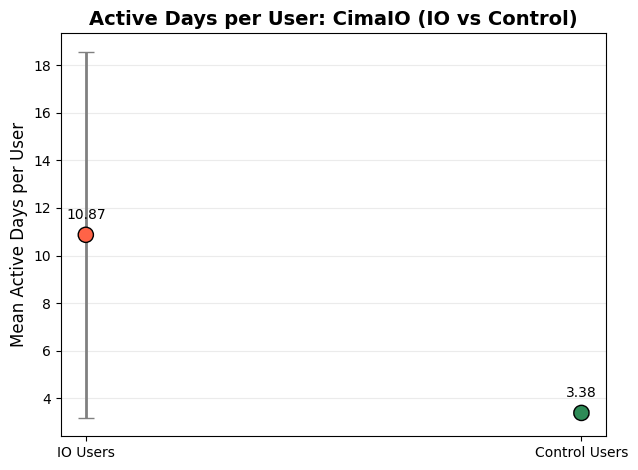

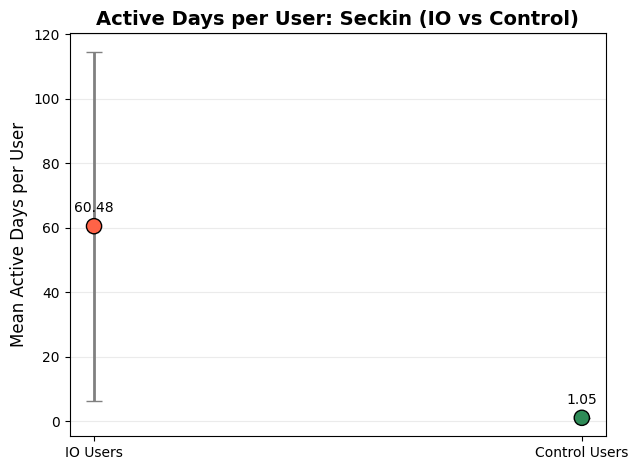

In [28]:
# Figures are generated in the previous cell.

In [21]:
# Print detailed statistics for each dataset
for name in sorted(results.keys()):
    result = results[name]
    
    print(f"\n{'='*60}")
    print(f"{name.upper()}")
    print(f"{'='*60}")
    
    # CimaIO stats (if available)
    if result.get('cima'):
        cima_io_posts = compute_statistics(result['cima']['io_posts'])
        cima_control_posts = compute_statistics(result['cima']['control_posts'])
        cima_io_days = compute_statistics(result['cima']['io_days'])
        cima_control_days = compute_statistics(result['cima']['control_days'])
        
        print(f"\nCimaIO Dataset:")
        print(f"  Posts/user - IO:      {cima_io_posts['mean']:>6.2f} ± {cima_io_posts['std']:>6.2f} ({cima_io_posts['count']:>6,} users)")
        print(f"  Posts/user - Control: {cima_control_posts['mean']:>6.2f} ± {cima_control_posts['std']:>6.2f} ({cima_control_posts['count']:>6,} users)")
        print(f"  Days/user  - IO:      {cima_io_days['mean']:>6.2f} ± {cima_io_days['std']:>6.2f}")
        print(f"  Days/user  - Control: {cima_control_days['mean']:>6.2f} ± {cima_control_days['std']:>6.2f}")
    
    # Seckin stats
    if result.get('seckin'):
        seckin_io_posts = compute_statistics(result['seckin']['io_posts'])
        seckin_control_posts = compute_statistics(result['seckin']['control_posts'])
        seckin_io_days = compute_statistics(result['seckin']['io_days'])
        seckin_control_days = compute_statistics(result['seckin']['control_days'])
        
        print(f"\nSeckin Dataset:")
        print(f"  Posts/user - IO:      {seckin_io_posts['mean']:>6.2f} ± {seckin_io_posts['std']:>6.2f} ({seckin_io_posts['count']:>6,} users)")
        print(f"  Posts/user - Control: {seckin_control_posts['mean']:>6.2f} ± {seckin_control_posts['std']:>6.2f} ({seckin_control_posts['count']:>6,} users)")
        print(f"  Days/user  - IO:      {seckin_io_days['mean']:>6.2f} ± {seckin_io_days['std']:>6.2f}")
        print(f"  Days/user  - Control: {seckin_control_days['mean']:>6.2f} ± {seckin_control_days['std']:>6.2f}")


ARMENIA

Seckin Dataset:
  Posts/user - IO:       20.08 ±  13.14 (    26 users)
  Posts/user - Control:  26.46 ±  43.36 ( 1,329 users)
  Days/user  - IO:        3.12 ±   2.24
  Days/user  - Control:   1.06 ±   0.51

BANGLADESH

Seckin Dataset:
  Posts/user - IO:      255.00 ± 329.93 (     4 users)
  Posts/user - Control:  26.20 ±  50.12 (   635 users)
  Days/user  - IO:       71.50 ±  73.70
  Days/user  - Control:   1.03 ±   0.39

CATALONIA

Seckin Dataset:
  Posts/user - IO:       82.38 ± 232.34 (    74 users)
  Posts/user - Control:  38.78 ±  52.09 ( 2,461 users)
  Days/user  - IO:       39.00 ±  76.57
  Days/user  - Control:   1.11 ±   0.48

CHINA_1

Seckin Dataset:
  Posts/user - IO:      774.03 ± 9389.49 (   460 users)
  Posts/user - Control:  30.72 ±  39.93 (33,417 users)
  Days/user  - IO:       35.45 ± 111.30
  Days/user  - Control:   1.04 ±   0.27

CHINA_2

Seckin Dataset:
  Posts/user - IO:      4042.59 ± 42443.48 (   166 users)
  Posts/user - Control:  16.80 ±  25.73 (20,16